# 40. Drawing unweighted events with `weighted_resample`

**Objectives:**
- Build a weighted phase-space sample whose per-event weight is the target signal density.
- Use `weighted_resample` to draw an unweighted event sample from that weighted pool.
- Confirm the unweighted histogram matches the original weighted histogram.

Run cells top to bottom in a fresh kernel. Masses are in GeV, invariants in GeV², daughter
indices start at zero.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes use complex128.

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    DecayChannel, DecayModel, NonResonant, RealImag, Resonance, weighted_resample,
)

## 1. Build a small model and a weighted phase-space sample

`generate_phase_space` gives a *weighted* proposal that is flat in the true phase-space
measure, not in the coherent intensity. Multiplying its integration weight by `model.intensity`
turns it into a weighted sample of the *signal* distribution — this is the
`w_target = w_PS * |A(x)|^2` convention documented in `weighted_resample`'s docstring.

In [2]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
components = [
    Resonance("rho", (0, 1), RealImag(1, 0), mass=0.7753, width=0.1491, spin=1),
    NonResonant(RealImag(0.5, -0.2), name="NR"),
]
model = DecayModel(
    channel, components, normalization_method="square-dalitz",
    normalization_resolution=100, normalization_pair=(0, 1),
)
truth = {p.name: p.value for p in model.parameters}

proposal = model.generate_phase_space(40000, seed=7, include_momenta=False)
target_weights = proposal.weights * model.intensity(proposal.as_dict(), truth)
print("Weighted pool size:", proposal.size)
print("Effective (weighted) mean intensity:", float(jnp.mean(target_weights)))

Weighted pool size: 40000
Effective (weighted) mean intensity: 9.431540949818647e-05


## 2. Resample an unweighted event sample

`weighted_resample` draws candidates from `proposal` with probability proportional to
`target_weights` and returns a sample with unit event weights, suitable as pseudo-data. The
candidate pool above is deliberately much larger than the requested pseudo-data size so
finite-pool duplication is negligible, as its docstring recommends.

In [3]:
key = jax.random.PRNGKey(2026)
resampled = weighted_resample(key, proposal, target_weights, size=6000)
print("Resampled events:", resampled.size)
assert np.all(np.asarray(resampled.weights) == 1.0)

Resampled events: 6000


## 3. Compare the unweighted and weighted histograms

Both histograms are density-normalized: `np.histogram(resampled.s12)` (unweighted counts) is
compared against `np.histogram(proposal.s12, weights=target_weights)` (the weighted pool it was
drawn from). They should agree within statistical fluctuations.

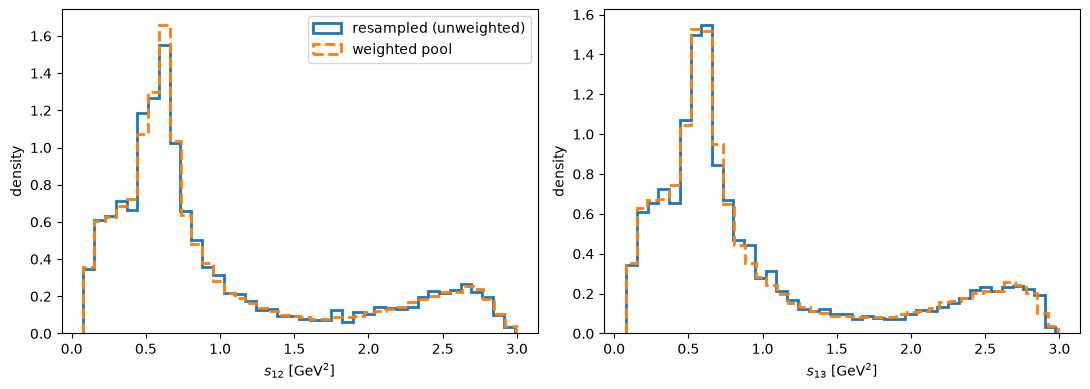

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = 40
for ax, key_name in zip(axes, ("s12", "s13")):
    ax.hist(
        np.asarray(getattr(resampled, key_name)), bins=bins, density=True,
        histtype="step", linewidth=2, label="resampled (unweighted)",
    )
    ax.hist(
        np.asarray(getattr(proposal, key_name)), bins=bins, density=True,
        weights=np.asarray(target_weights),
        histtype="step", linewidth=2, linestyle="--", label="weighted pool",
    )
    ax.set(xlabel=f"${key_name[0]}_{{{key_name[1:]}}}$ [GeV$^2$]", ylabel="density")
axes[0].legend()
fig.tight_layout()
plt.show()

## 4. A simple numerical agreement check

In [5]:
edges = np.histogram_bin_edges(np.asarray(proposal.s12), bins=25)
hist_resampled, _ = np.histogram(np.asarray(resampled.s12), bins=edges, density=True)
hist_weighted, _ = np.histogram(
    np.asarray(proposal.s12), bins=edges, weights=np.asarray(target_weights), density=True,
)
max_abs_diff = float(np.max(np.abs(hist_resampled - hist_weighted)))
print(f"Max |density difference| across s12 bins: {max_abs_diff:.4f}")
assert max_abs_diff < 0.5, "resampled and weighted histograms disagree beyond expected statistical spread"
print("The unweighted resample matches the weighted pool it was drawn from.")

Max |density difference| across s12 bins: 0.0774
The unweighted resample matches the weighted pool it was drawn from.


## Summary and exercises

1. `weighted_resample` is the resampling building block behind `generate_toy(..., method="resample")`
   — it does not generate a new weighted pool itself, only draws unweighted events from one you supply.
2. The returned sample always has unit event weights, so it can be treated as ordinary pseudo-data.
3. Make the candidate pool larger and watch `max_abs_diff` shrink further.
4. Try `replace=False`: this requires `size <= proposal.size` and avoids duplicate candidate events.

Reference: [toy generation](../../docs/toy_generation.md), [MC integration conventions](../../docs/mc_integration.md).

Return to [the course guide](TUTORIALS.md).